In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [2]:
credit_card_data = pd.read_csv('credit_data.csv')
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
credit_card_data.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

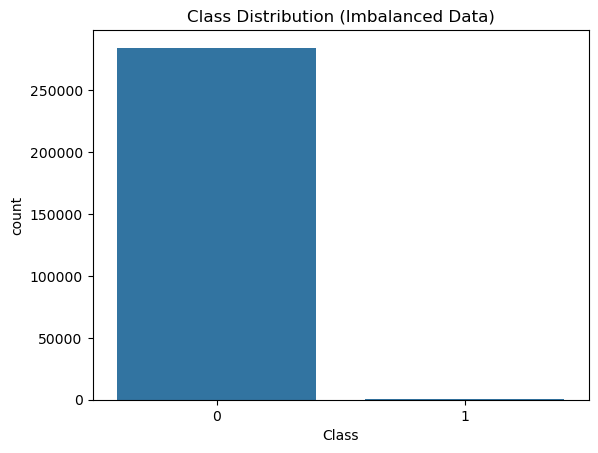

In [6]:
sns.countplot(x='Class', data=credit_card_data)
plt.title("Class Distribution (Imbalanced Data)")
plt.show()

In [7]:
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]

print("Legit:", legit.shape)
print("Fraud:", fraud.shape)

Legit: (284315, 31)
Fraud: (492, 31)


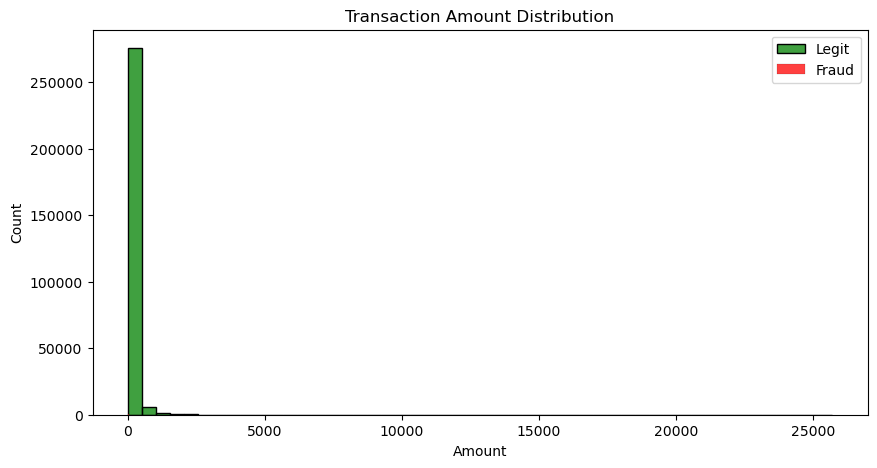

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(legit['Amount'], bins=50, color='green', label='Legit')
sns.histplot(fraud['Amount'], bins=50, color='red', label='Fraud')
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

In [9]:
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


## Under-Sampling()


In [10]:
legit_sample = legit.sample(n=492, random_state=2)

new_dataset = pd.concat([legit_sample, fraud], axis=0)
new_dataset['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

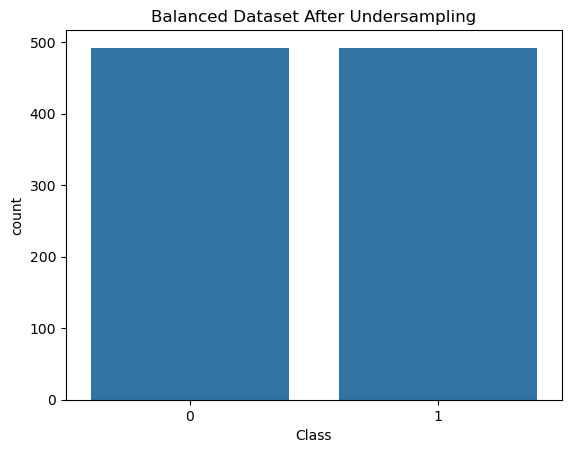

In [11]:
sns.countplot(x='Class', data=new_dataset)
plt.title("Balanced Dataset After Undersampling")
plt.show()

In [12]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=2
)

print(X_train.shape, X_test.shape)

(787, 30) (197, 30)


## Logistic Regression

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

C:\Users\Mekala Abhilash\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [15]:
def evaluate_model(model, X, Y):
    preds = model.predict(X)
    return {
        "Accuracy": accuracy_score(Y, preds),
        "Precision": precision_score(Y, preds),
        "Recall": recall_score(Y, preds),
        "F1": f1_score(Y, preds)
    }


In [16]:
train_metrics = evaluate_model(model, X_train, Y_train)
test_metrics = evaluate_model(model, X_test, Y_test)

train_metrics, test_metrics

({'Accuracy': 0.951715374841169,
  'Precision': 0.9759358288770054,
  'Recall': 0.9263959390862944,
  'F1': 0.9505208333333334},
 {'Accuracy': 0.9289340101522843,
  'Precision': 0.9565217391304348,
  'Recall': 0.8979591836734694,
  'F1': 0.9263157894736842})

## LINE GRAPH – Train vs Test Performance

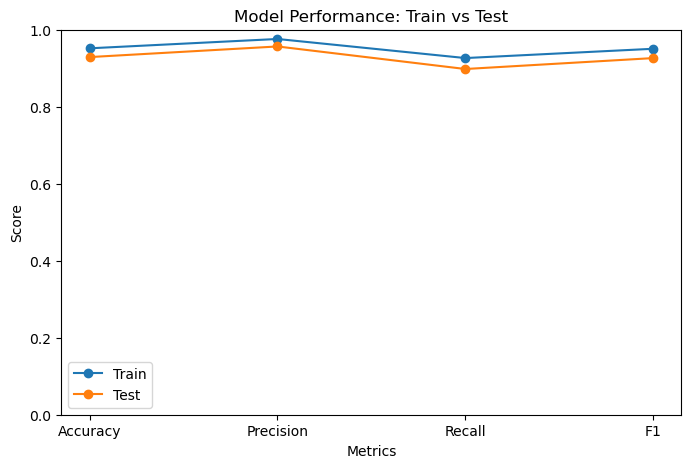

In [18]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

train_values = [train_metrics[m] for m in metrics]
test_values = [test_metrics[m] for m in metrics]

plt.figure(figsize=(8,5))
plt.plot(metrics, train_values, marker='o', label='Train')
plt.plot(metrics, test_values, marker='o', label='Test')

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Performance: Train vs Test")
plt.legend()
plt.ylim(0,1)
plt.show()

## LINE GRAPH – Prediction Confidence Change

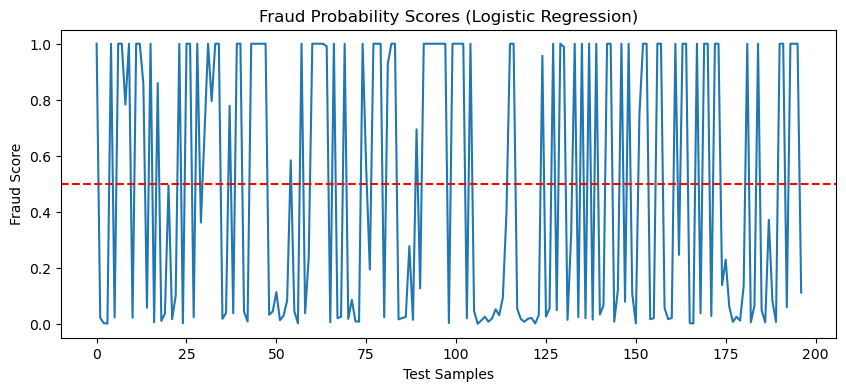

In [19]:
probabilities = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(10,4))
plt.plot(probabilities)
plt.axhline(y=0.5, color='red', linestyle='--')
plt.title("Fraud Probability Scores (Logistic Regression)")
plt.ylabel("Fraud Score")
plt.xlabel("Test Samples")
plt.show()

In [21]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 131.3 kB/s eta 0:09:09
   ---------------------------------------- 0.0/72.0 MB 163.8 kB/s eta 0:07:20
   ---------------------------------------- 0.1/72.0 MB 297.7 kB/s eta 0:04:02
   ---------------------------------------- 0.3/72.0 MB 1.5 MB/s eta 0:00:48
   ---------------------------------------- 0.7/72.0 MB 2.9 MB/s eta 0:00:25
   ---------------------------------------- 0.9/72.0 MB 3.0 MB/s eta 0:00:24
    --------------------------------------- 1.0/72.0 MB 3.2 MB/s eta 0:00:23
    --------------------------------------- 1.0/72.0 MB 3.2 MB/s eta 0:00:23
    --------------------------------------- 1.0/72.0 MB 3.2 MB/s eta 0:00:23
    -----------------

In [22]:
from xgboost import XGBClassifier

In [23]:
fraud_count = Y_train.value_counts()[1]
legit_count = Y_train.value_counts()[0]

scale_pos_weight = legit_count / fraud_count
scale_pos_weight

0.9974619289340102

## Train XGBoost Model (Overfitting Controlled)

In [24]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)

xgb_model.fit(X_train, Y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [26]:
threshold = 0.2
xgb_pred = (xgb_prob > threshold).astype(int)

## Logistic vs XGBoost Comparison

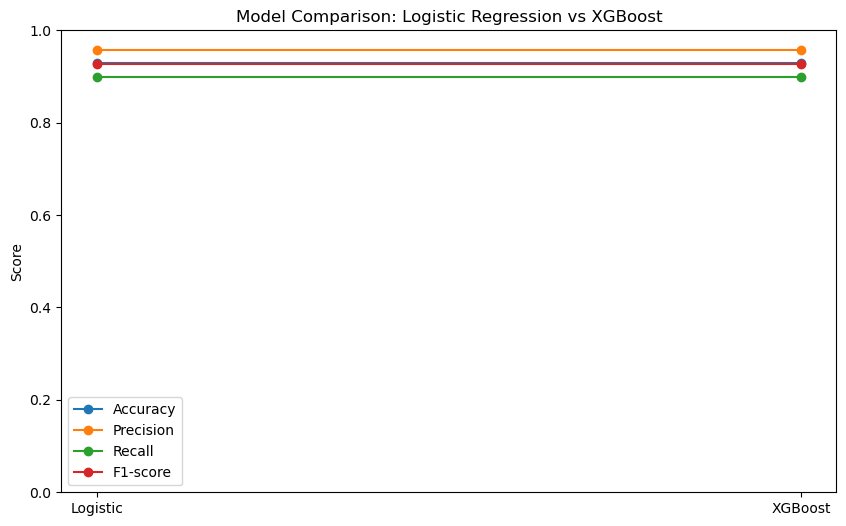

In [28]:
models = ['Logistic', 'XGBoost']
accuracy = [test_metrics['Accuracy'], xgb_metrics['Accuracy']]
precision = [test_metrics['Precision'], xgb_metrics['Precision']]
recall = [test_metrics['Recall'], xgb_metrics['Recall']]
f1 = [test_metrics['F1'], xgb_metrics['F1']]

plt.figure(figsize=(10,6))
plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='o', label='Recall')
plt.plot(models, f1, marker='o', label='F1-score')

plt.title("Model Comparison: Logistic Regression vs XGBoost")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.show()


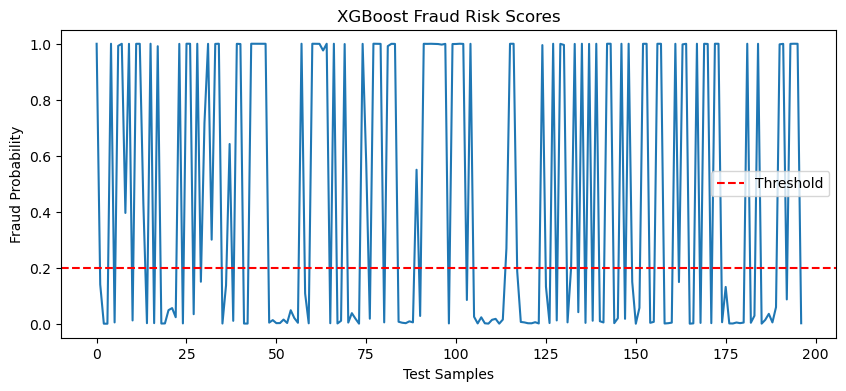

In [29]:
plt.figure(figsize=(10,4))
plt.plot(xgb_prob)
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
plt.title("XGBoost Fraud Risk Scores")
plt.xlabel("Test Samples")
plt.ylabel("Fraud Probability")
plt.legend()
plt.show()


In [30]:
def evaluate_model_scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

xgb_metrics = evaluate_model_scores(Y_test, xgb_pred)
xgb_metrics

{'Accuracy': 0.9289340101522843,
 'Precision': 0.9565217391304348,
 'Recall': 0.8979591836734694,
 'F1': 0.9263157894736842}

In [32]:
import pickle
with open('logistic_fraud_model.pkl', 'wb') as file:
    pickle.dump(model, file)


In [33]:
with open('xgboost_fraud_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)